# QAOA Model Evaluation
Compares ADAPT baseline against multiple GPT/LLaMA-based QAOA circuit generators.

# IMPORTS

In [1]:
# ------------------------
# IMPORTS
# ------------------------

import random
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

from src.adapt_utils import compute_metrics_per_graph
from src.model_interface import QAOA_GPT
from src.utils import (
    attach_resolved_names,
    load_and_aggregate_adapt,
    build_results_df,
    build_final_df,
    build_summary_df,
)

pd.set_option("display.max_columns", None)

In [2]:
# MODEL_CONFIGS = [
#     dict(
#         ckpt="nanoGPT/out-10_nodes_feather/llama_ckpt_6500_feather_ar_0_93013__er_0_12.pt",
#         data_dir="nanoGPT/data/10_nodes_feather",
#     ),
#     dict(
#         ckpt="nanoGPT/out-10_nodes_gnn/llama_ckpt_4500_gnn_ar_0_87058__er_0_01.pt",
#         data_dir="nanoGPT/data/10_nodes_gnn",
#     ),
#     dict(
#         ckpt="nanoGPT/out-10_nodes_netlsd/llama_ckpt_6000_netlsd_ar_0_9436__er_0_026.pt",
#         data_dir="nanoGPT/data/10_nodes_netlsd",
#     ),
#     dict(
#         ckpt="nanoGPT/out-10_nodes_feather/gpt_ckpt_3500_feather_ar_0_96305__er_0_0.pt",
#         data_dir="nanoGPT/data/10_nodes_feather",
#     ),
#     dict(
#         ckpt="nanoGPT/out-10_nodes_gnn/gpt_ckpt_3000_gnn_ar_0_95227__er_0_0.pt",
#         data_dir="nanoGPT/data/10_nodes_gnn",
#     ),
#     dict(
#         ckpt="nanoGPT/out-10_nodes_netlsd/gpt_ckpt_4500_netlsd_ar_0_95556__er_0_0.pt",
#         data_dir="nanoGPT/data/10_nodes_netlsd",
#     ),
#     dict(
#         name="GPT-Feather (Author)",
#         ckpt="nanoGPT/models/n10w_qaoa_mixer/ckpt_16000_gemb__ar_0_96584__er_0_0.pt",
#         data_dir="nanoGPT/models/n10w_qaoa_mixer/data",
#     ),
# ]

In [3]:
# MODEL_CONFIGS = [
#     dict(
#         ckpt="nanoGPT/out-9_nodes_feather/llama_ckpt_7000_feather_ar_0_94805__er_0_0.pt",
#         data_dir="nanoGPT/data/9_nodes_feather",
#     ),
#     dict(
#         ckpt="nanoGPT/out-9_nodes_gnn/llama_ckpt_4500_gnn_ar_0_92291__er_0_0.pt",
#         data_dir="nanoGPT/data/9_nodes_gnn",
#     ),
#     dict(
#         ckpt="nanoGPT/out-9_nodes_netlsd/llama_ckpt_4500_netlsd_ar_0_89075__er_0_0.pt",
#         data_dir="nanoGPT/data/9_nodes_netlsd",
#     ),
#     dict(
#         ckpt="nanoGPT/out-9_nodes_feather/gpt_ckpt_2000_feather_ar_0_95739__er_0_0.pt",
#         data_dir="nanoGPT/data/9_nodes_feather",
#     ),
#     dict(
#         ckpt="nanoGPT/out-9_nodes_gnn/gpt_ckpt_4500_gnn_ar_0_95905__er_0_0.pt",
#         data_dir="nanoGPT/data/9_nodes_gnn",
#     ),
#     dict(
#         ckpt="nanoGPT/out-9_nodes_netlsd/gpt_ckpt_3000_netlsd_ar_0_95822__er_0_0.pt",
#         data_dir="nanoGPT/data/9_nodes_netlsd",
#     ),
# ]

In [ ]:
MODEL_CONFIGS = [
    dict(
        ckpt="nanoGPT/out-11_nodes_feather/llama_ckpt_5000_feather_ar_0_89184__er_0_0.pt",
        data_dir="nanoGPT/data/11_nodes_feather",
    ),
    dict(
        ckpt="nanoGPT/out-11_nodes_gnn/llama_ckpt_4500_gnn_ar_0_91473__er_0_0.pt",
        data_dir="nanoGPT/data/11_nodes_gnn",
    ),
    dict(
        ckpt="nanoGPT/out-11_nodes_netlsd/llama_ckpt_5000_netlsd_ar_0_9264__er_0_0.pt",
        data_dir="nanoGPT/data/11_nodes_netlsd",
    ),
    dict(
        ckpt="nanoGPT/out-11_nodes_feather/gpt_ckpt_3000_feather_ar_0_96249__er_0_0.pt",
        data_dir="nanoGPT/data/11_nodes_feather",
    ),
    dict(
        ckpt="nanoGPT/out-11_nodes_gnn/gpt_ckpt_2500_gnn_ar_0_95371__er_0_0.pt",
        data_dir="nanoGPT/data/11_nodes_gnn",
    ),
    dict(
        ckpt="nanoGPT/out-11_nodes_netlsd/gpt_ckpt_4000_netlsd_ar_0_96605__er_0_0.pt",
        data_dir="nanoGPT/data/11_nodes_netlsd",
    ),
]

In [5]:
# ------------------------
# CONFIG
# ------------------------

SEED = 1337
n_nodes = 11
data_input_path = f"./ADAPT.jl_results/test/{n_nodes}_nodes"
save_path = f"docs/{n_nodes}_nodes/{n_nodes}_nodes.csv"

# Model configs — each entry is a dict with required keys: ckpt, data_dir.
# Optional key: name (auto-extracted from ckpt filename if omitted).
# Auto-extraction: splits filename by "_", takes element[0] as arch and element[3] as method.
# Example: "llama_ckpt_5500_gnn_ar_0_924__er_0_006.pt" → "LLaMA-GNN"
# If name is provided explicitly, it overrides auto-extraction.


N_SAMPLES   = 5
MAX_TOKENS  = 150

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
# Attach resolved_name / arch / method to every config
MODEL_CONFIGS = attach_resolved_names(MODEL_CONFIGS)
print(f"MODEL_CONFIGS: {MODEL_CONFIGS}")

Resolved model names:
  LLaMA-Feather  (arch=LLaMA, method=Feather)
MODEL_CONFIGS: [{'ckpt': 'nanoGPT/out-11_nodes_feather/llama_ckpt_5000_feather_ar_0_89184__er_0_0.pt', 'data_dir': 'nanoGPT/data/11_nodes_feather', 'resolved_name': 'LLaMA-Feather', 'arch': 'LLaMA', 'method': 'Feather'}]


# LOAD ADAPT & GRAPHS

In [6]:
# ------------------------
# LOAD ADAPT & GRAPHS
# ------------------------

adapt_df, adapt_agg, graphs_unique, meta_df = load_and_aggregate_adapt(data_input_path)

Reading ADAPT.jl results from:
	 /home/mrzaizai2k/code_bao/ADAPT_GPT/ADAPT.jl_results/test/11_nodes


Opening ADAPT results (11_nodes): 100%|██████████| 1/1 [00:00<00:00, 15.83it/s]


df_list len: 1


Opening graphs (11_nodes): 100%|██████████| 1/1 [00:00<00:00, 663.34it/s]

df_list len: 1
Graphs count:
g_method
erdos_renyi    100
Name: count, dtype: int64
Aggregating results...
Total ADAPT rows      : 154
Unique graphs         : 100
Runs per graph (mean) : 1.54

Aggregated ADAPT shape : (100, 9)
Graphs fed to model    : 100


In [7]:
adapt_agg.tail()

,graph_num,graph_name,adapt_ar_mean,adapt_time_mean,adapt_ar_best,adapt_ar_std,adapt_layers_mean,adapt_layers_best,adapt_n_runs
95,96,Graph_96,0.953299,32.381328,0.971898,0.025856,19.666667,9,3
96,97,Graph_97,0.969097,39.330580,0.970040,0.001334,19.500000,14,2
97,98,Graph_98,0.986041,5.100803,0.986041,0.000000,11.000000,11,1
98,99,Graph_99,0.985823,3.072856,0.985823,0.000000,9.000000,9,1
99,100,Graph_100,0.976252,10.127592,0.976252,0.000000,9.000000,9,1


# Run data

In [10]:
# ------------------------
# MODEL UTILS
# ------------------------

all_results = []

for cfg in MODEL_CONFIGS:
    model_name = cfg["resolved_name"]
    print(f"\nRunning {model_name} ...")

    model = QAOA_GPT(
        model_ckpt=cfg["ckpt"],
        data_dir=cfg["data_dir"],
    )
    df_model = model.generate_circ_from_nx(
        graphs_unique,
        num_samples=N_SAMPLES,
        max_new_tokens=MAX_TOKENS,
        temperature=0.1,
        top_k=200,
    )

    df_eval = model.eval_circ_df_jl(df_model)

    ar, layers, error_rate = compute_metrics_per_graph(df_eval)

    all_results.append(build_results_df(meta_df, cfg, ar, layers, error_rate))

model_results_df = pd.concat(all_results, ignore_index=True)


Running LLaMA-Feather ...

Model type: llama
Pool type: qaoa_double_pool
Embedding method: feather
Number of nodes: 11


Preparing graphs...: 100%|██████████| 100/100 [00:00<00:00, 238.65it/s]


Performing feather embedding


100%|██████████| 100/100 [00:00<00:00, 2038.32it/s]
Inference. Current batch: n_edges: 15, n_graphs: 1: 100%|██████████| 40/40 [00:38<00:00,  1.03it/s]



===== DEBUG INFO =====
CWD: /home/mrzaizai2k/code_bao/ADAPT_GPT
Command:
/opt/julia-1.12.1/bin/julia -t 4 --project=/home/mrzaizai2k/code_bao/ADAPT_GPT/ADAPT.jl /home/mrzaizai2k/code_bao/ADAPT_GPT/adapt_gpt_eval_energy.jl /home/mrzaizai2k/code_bao/ADAPT_GPT/temp_data/adapt_gpt_res_2026-05-08__17_07_32_df.json /home/mrzaizai2k/code_bao/ADAPT_GPT/temp_data/adapt_gpt_res_2026-05-08__17_07_32_df_jl.json 11 qaoa_double_pool


Julia return code: 0


In [12]:
model_results_df.head()

,graph_name,graph_num,model,arch,method,model_ar,model_layers,model_error_rate
0,Graph_1,1,LLaMA-Feather,LLaMA,Feather,0.915784,12.4,0.0
1,Graph_2,2,LLaMA-Feather,LLaMA,Feather,0.879932,12.8,0.0
2,Graph_3,3,LLaMA-Feather,LLaMA,Feather,0.838844,13.8,0.0
3,Graph_4,4,LLaMA-Feather,LLaMA,Feather,0.849654,11.4,0.0
4,Graph_5,5,LLaMA-Feather,LLaMA,Feather,0.90912,10.6,0.0


<!-- # MERGE & SUMMARY -->

# Load QAOA result (Optional)

In [11]:
qaoa_df = pd.read_csv(f"{data_input_path}/qaoa_result/qaoa.csv")

In [ ]:
# final_df = pd.read_csv(f'docs/11_nodes/11_nodes.csv')

In [13]:
# ------------------------
# MERGE & SUMMARY
# ------------------------

final_df   = build_final_df(adapt_agg, model_results_df, qaoa_df=qaoa_df)

In [14]:
final_df = final_df[final_df['model'] != "GPT-Feather (Author)"] 

In [15]:

summary_df = build_summary_df(final_df)

print(summary_df.to_string(index=False))

        model  arch  method  adapt_ar_mean  adapt_ar_best  adapt_layers  adapt_time_mean  model_ar  model_error_rate  model_layers  qaoa_ar_mean  qaoa_ar_best  qaoa_layers  qaoa_time_mean
LLaMA-Feather LLaMA Feather       0.971006       0.975903     15.406667        29.161799  0.912781               0.0        14.896      0.873778      0.919113         11.0      129.166052


In [77]:
# import os

# # Ensure the directory exists
# os.makedirs(os.path.dirname(save_path), exist_ok=True)

# # Check if file exists
# if not os.path.isfile(save_path):
#     # Save DataFrame to CSV
#     final_df.to_csv(save_path, index=False)
# else:
#     pass

In [78]:
len(final_df)

600

In [79]:
final_df.head(10)

,graph_num,graph_name,adapt_ar_mean,adapt_time_mean,adapt_ar_best,adapt_ar_std,adapt_layers_mean,adapt_layers_best,adapt_n_runs,model,arch,method,model_ar,model_layers,model_error_rate,qaoa_ar_mean,qaoa_ar_best,qaoa_time_mean,qaoa_layers
0,1,Graph_1,0.955570,40.096884,0.970030,0.02045,24.5,24,2,LLaMA-Feather,LLaMA,Feather,0.915784,12.4,0.0,0.851928,0.919495,95.2174,11
1,1,Graph_1,0.955570,40.096884,0.970030,0.02045,24.5,24,2,LLaMA-GNN,LLaMA,GNN,0.905702,12.8,0.0,0.851928,0.919495,95.2174,11
2,1,Graph_1,0.955570,40.096884,0.970030,0.02045,24.5,24,2,LLaMA-NetLSD,LLaMA,NetLSD,0.943202,9.6,0.0,0.851928,0.919495,95.2174,11
3,1,Graph_1,0.955570,40.096884,0.970030,0.02045,24.5,24,2,NanoGPT-Feather,NanoGPT,Feather,0.959338,8.0,0.0,0.851928,0.919495,95.2174,11
4,1,Graph_1,0.955570,40.096884,0.970030,0.02045,24.5,24,2,NanoGPT-GNN,NanoGPT,GNN,0.938149,7.0,0.0,0.851928,0.919495,95.2174,11
5,1,Graph_1,0.955570,40.096884,0.970030,0.02045,24.5,24,2,NanoGPT-NetLSD,NanoGPT,NetLSD,0.962922,9.4,0.0,0.851928,0.919495,95.2174,11
6,2,Graph_2,0.984925,5.917113,0.984925,0.00000,9.0,9,1,LLaMA-Feather,LLaMA,Feather,0.879932,12.8,0.0,0.862916,0.883162,173.0484,11
7,2,Graph_2,0.984925,5.917113,0.984925,0.00000,9.0,9,1,LLaMA-GNN,LLaMA,GNN,0.871782,18.2,0.0,0.862916,0.883162,173.0484,11
8,2,Graph_2,0.984925,5.917113,0.984925,0.00000,9.0,9,1,NanoGPT-Feather,NanoGPT,Feather,0.948560,8.0,0.0,0.862916,0.883162,173.0484,11
9,2,Graph_2,0.984925,5.917113,0.984925,0.00000,9.0,9,1,LLaMA-NetLSD,LLaMA,NetLSD,0.927608,10.0,0.0,0.862916,0.883162,173.0484,11


# Plot helpers

In [80]:
# ============================================================
# SCALABLE PLOTS — one figure per metric
# ============================================================

ADAPT_PALETTE = {"mean": "#4C72B0", "best": "#55A868", "std_fill": "#4C72B0"}

def _place_legend_outside(ax, fig, ncol=1):
    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        fontsize=8,
        frameon=False,
        ncol=ncol,
    )
    fig.tight_layout(rect=[0, 0, 0.82, 1])  # leave space on right

def _model_colors(models):
    """Assign a stable color per model name."""
    palette = ["#C44E52", "#DD8452", "#8172B2", "#937860", "#DA8BC3", "#8C8C8C"]
    return {m: palette[i % len(palette)] for i, m in enumerate(models)}

def plot_ar_bar(summary_df, plot_best = False):
    models = summary_df["model"].tolist()
    x = np.arange(len(models))
    w = 0.35

    fig, ax = plt.subplots(figsize=(max(6, len(models) * 2.2) + 2, 5))

    # --- MODEL COLORS ---
    mc = _model_colors(models)

    # --- MODEL BARS ---
    for i, (_, row) in enumerate(summary_df.iterrows()):
        ax.bar(
            x[i],
            row["model_ar"],
            w,
            color=mc[row["model"]],
            label=row["model"]
        )

    # --- ADAPT (COLD TONES) ---
    adapt_mean = summary_df["adapt_ar_mean"].iloc[0]

    ax.axhline(adapt_mean, linestyle="--",
               color="#4C72B0", linewidth=2, label="ADAPT (mean)")

    if plot_best and 'adapt_ar_best' in summary_df.columns:    
        adapt_best = summary_df["adapt_ar_best"].iloc[0]

        ax.axhline(adapt_best, linestyle="-.",
                   color="#2A4D69", linewidth=2, label="ADAPT (best)")

    # --- QAOA (HOT TONES) ---
    if "qaoa_ar_mean" in summary_df.columns:
        qaoa_mean = summary_df["qaoa_ar_mean"].iloc[0]
        ax.axhline(qaoa_mean, linestyle="--",
                   color="#DD8452", linewidth=2, label="QAOA (mean)")
        
        if plot_best and 'qaoa_ar_best' in summary_df.columns:
            qaoa_best = summary_df["qaoa_ar_best"].iloc[0]

            ax.axhline(qaoa_best, linestyle="-.",
                       color="#C44E52", linewidth=2, label="QAOA (best)")

    # --- AXIS ---
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=15, ha="right")
    ax.set_ylabel("Approximation Ratio")
    ax.set_title("Approximation Ratio Comparison")

    ymin = min(
        summary_df["model_ar"].min(),
        adapt_mean,
        summary_df.get("qaoa_ar_mean", pd.Series([adapt_mean])).iloc[0]
    ) - 0.1

    ax.set_ylim(ymin, 1.01)
    ax.grid(axis="y", alpha=0.4)

    # --- LEGEND (NO DUPLICATES) ---
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(),
              bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()
    plt.show()

def plot_layers_bar(summary_df):
    models = summary_df["model"].tolist()
    x = np.arange(len(models))
    w = 0.4

    fig, ax = plt.subplots(figsize=(max(6, len(models) * 2) + 4, 5))

    # --- MODEL COLORS ---
    mc = _model_colors(models)

    # --- MODEL BARS ---
    for i, (_, row) in enumerate(summary_df.iterrows()):
        ax.bar(
            x[i],
            row["model_layers"],
            w,
            color=mc[row["model"]],
            label=row["model"]
        )

    # --- ADAPT (COLD) ---
    adapt_layers = summary_df["adapt_layers"].iloc[0]
    ax.axhline(adapt_layers, linestyle="--",
               color="#4C72B0", linewidth=2, label="ADAPT")

    # --- QAOA (HOT) ---
    if "qaoa_layers" in summary_df.columns:
        qaoa_layers = summary_df["qaoa_layers"].iloc[0]
        ax.axhline(qaoa_layers, linestyle="-.",
                   color="#DD8452", linewidth=2, label="QAOA")

    # --- AXIS ---
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=15, ha="right")
    ax.set_ylabel("Layers")
    ax.set_title("Circuit Depth Comparison")

    ax.grid(axis="y", alpha=0.4)

    # --- LEGEND CLEAN ---
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(),
              bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()
    plt.show()

def plot_error_rate_bar(summary_df):
    models = summary_df["model"].tolist()
    mc     = _model_colors(models)
    x      = np.arange(len(models))

    fig, ax = plt.subplots(figsize=(max(6, len(models) * 2), 5))

    for i, (_, row) in enumerate(summary_df.iterrows()):
        ax.bar(x[i], row["model_error_rate"],
               color=mc[row["model"]], label=row["model"])

    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=15, ha="right")
    ax.set_ylabel("Error Rate")
    ax.set_title("Model Error Rate")
    ax.set_ylim(0, min(1.0, summary_df["model_error_rate"].max() + 0.05))
    ax.grid(axis="y", alpha=0.4)

    _place_legend_outside(ax, fig)
    plt.show()

def plot_ar_vs_layers_scatter(final_df, plot_best=False):
    models = final_df["model"].unique().tolist()
    mc     = _model_colors(models)

    fig, ax = plt.subplots(figsize=(13, 7))

    ax.scatter(final_df["adapt_layers_mean"], final_df["adapt_ar_mean"],
               label="ADAPT (mean)", alpha=0.5, color=ADAPT_PALETTE["mean"])
    
    if plot_best and 'adapt_layers_best' in final_df.columns and 'adapt_ar_best' in final_df.columns:
        ax.scatter(final_df["adapt_layers_best"], final_df["adapt_ar_best"],
                label="ADAPT (best)", alpha=0.5, color=ADAPT_PALETTE["best"], marker="^")

    if "qaoa_ar_mean" in final_df.columns:
        ax.scatter(final_df["qaoa_layers"], final_df["qaoa_ar_mean"],
                   label="QAOA", alpha=0.5, color="#64B5CD", marker="x")

    for model, grp in final_df.groupby("model"):
        ax.scatter(grp["model_layers"], grp["model_ar"],
                   label=model, alpha=0.7, color=mc[model])

    ax.set_xlabel("Layers")
    ax.set_ylabel("Approximation Ratio")
    ax.set_title("AR vs Layers Trade-off")
    ax.grid(alpha=0.4)

    _place_legend_outside(ax, fig)
    plt.show()

def plot_per_graph_ar(final_df):
    models      = final_df["model"].unique().tolist()
    mc          = _model_colors(models)
    graph_order = sorted(final_df["graph_num"].unique())

    adapt_base = (
        final_df[final_df["model"] == models[0]]
        .set_index("graph_num")
        .reindex(graph_order)
    )

    fig, ax = plt.subplots(figsize=(max(10, len(graph_order) // 5), 5))

    ax.plot(graph_order, adapt_base["adapt_ar_mean"],
            label="ADAPT (mean)", color=ADAPT_PALETTE["mean"])

    ax.fill_between(
        graph_order,
        adapt_base["adapt_ar_mean"] - adapt_base["adapt_ar_std"],
        adapt_base["adapt_ar_mean"] + adapt_base["adapt_ar_std"],
        alpha=0.12, color=ADAPT_PALETTE["mean"],
    )

    if "qaoa_ar_mean" in final_df.columns:
        ax.plot(graph_order, adapt_base["qaoa_ar_mean"],
                label="QAOA", color="#64B5CD", linestyle="--")

    for model, grp in final_df.groupby("model"):
        grp = grp.set_index("graph_num").reindex(graph_order)
        ax.plot(graph_order, grp["model_ar"],
                label=model, color=mc[model])

    ax.set_xlabel("Graph number")
    ax.set_ylabel("Approximation Ratio")
    ax.set_title("Per-graph AR Comparison")
    ax.grid(alpha=0.4)

    _place_legend_outside(ax, fig)
    plt.show()


# Run all plots

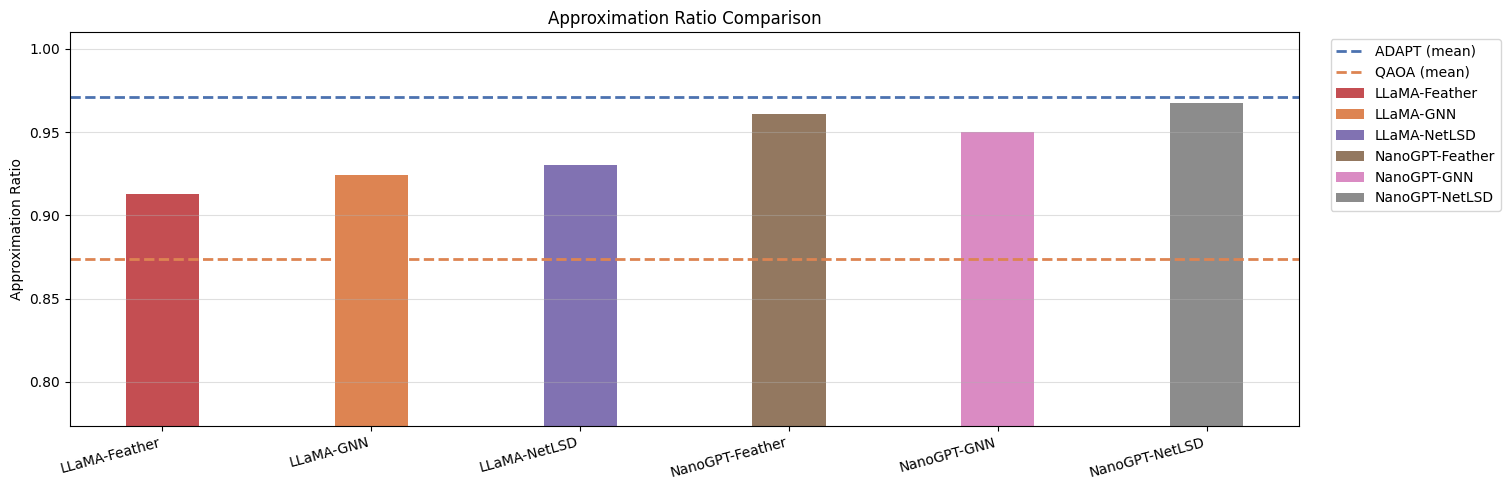

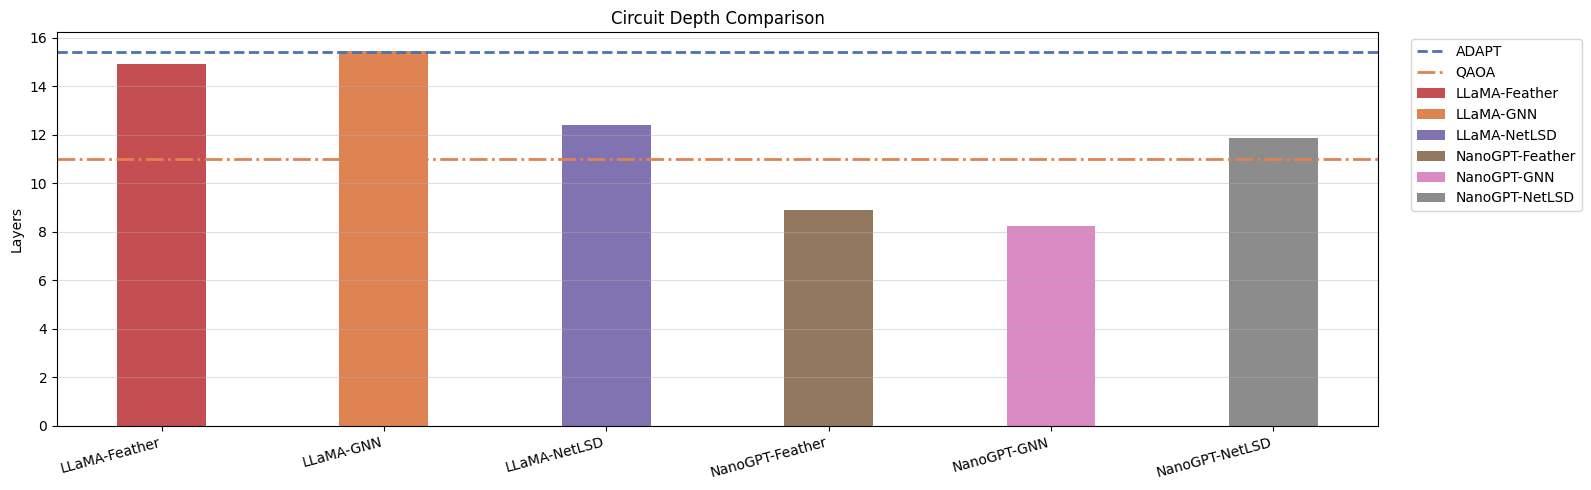

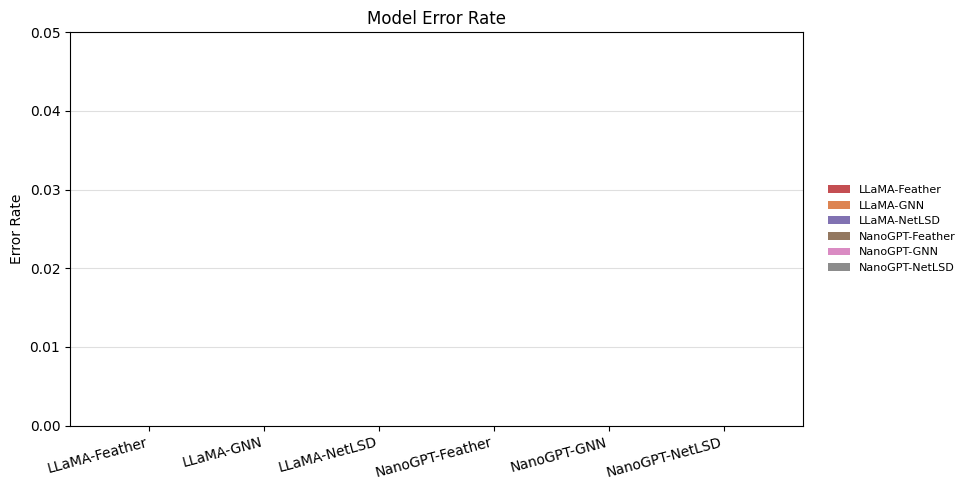

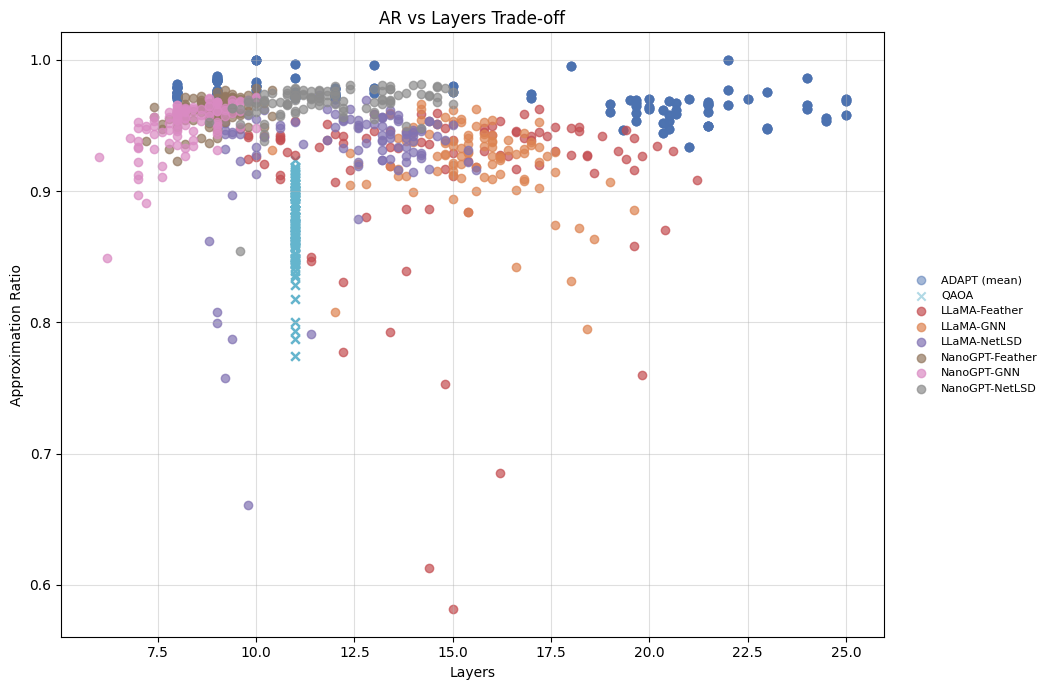

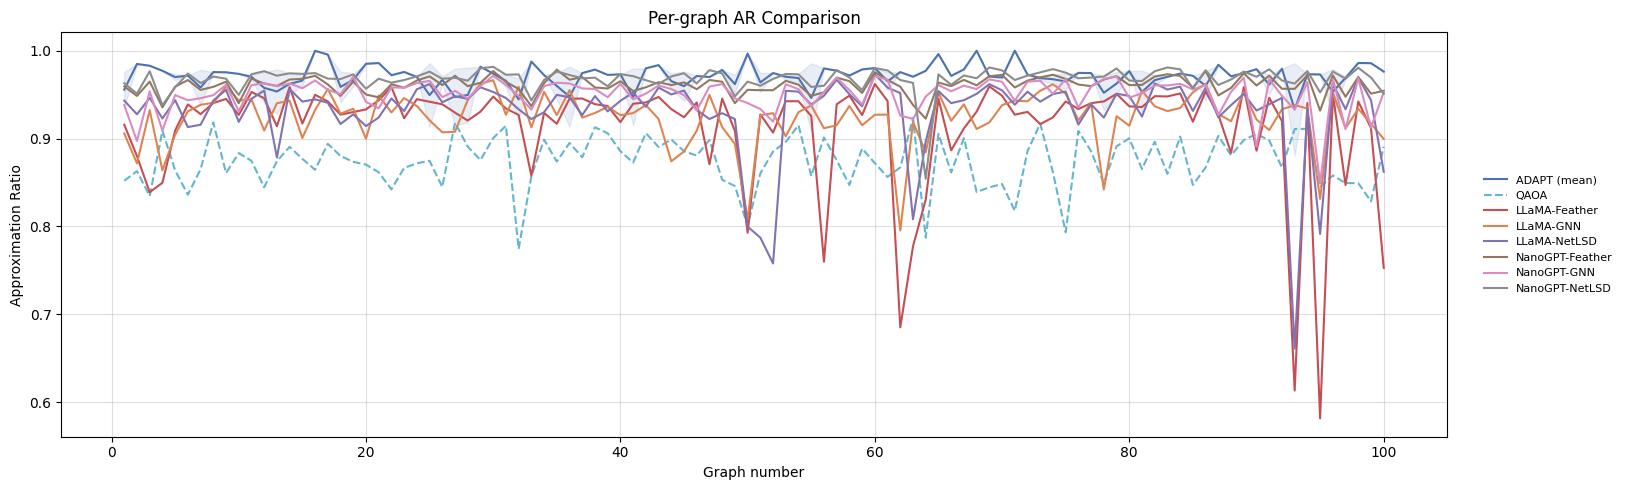

In [81]:
# ── Run all plots ──────────────────────────────────────────────────────────

plot_ar_bar(summary_df, plot_best=False)
plot_layers_bar(summary_df)
plot_error_rate_bar(summary_df)
plot_ar_vs_layers_scatter(final_df)
plot_per_graph_ar(final_df)

# EXTRA INSIGHTS

In [82]:
# ------------------------
# EXTRA INSIGHTS (CLEAN)
# ------------------------

print("=" * 55)
print("INSIGHTS")
print("=" * 55)

for _, row in summary_df.iterrows():
    print(f"\nModel : {row['model']}")
    
    print(f"  ADAPT AR (mean / best): {row['adapt_ar_mean']:.4f} / {row['adapt_ar_best']:.4f}")
    print(f"  Model AR              : {row['model_ar']:.4f}")
    
    if "qaoa_ar_mean" in row:
        print(f"  QAOA AR (mean / best) : {row['qaoa_ar_mean']:.4f} / {row['qaoa_ar_best']:.4f}")
    
    print(f"  ADAPT layers (mean)   : {row['adapt_layers']:.2f}")
    print(f"  Model layers          : {row['model_layers']:.2f}")
    
    if "qaoa_layers" in row:
        print(f"  QAOA layers           : {row['qaoa_layers']:.2f}")
    
    print(f"  Model error rate      : {row['model_error_rate']:.4f}")
    
    if "qaoa_time_mean" in row:
        print(f"  QAOA time (mean)      : {row['qaoa_time_mean']:.2f}s")

INSIGHTS

Model : LLaMA-Feather
  ADAPT AR (mean / best): 0.9710 / 0.9759
  Model AR              : 0.9128
  QAOA AR (mean / best) : 0.8738 / 0.9191
  ADAPT layers (mean)   : 15.41
  Model layers          : 14.90
  QAOA layers           : 11.00
  Model error rate      : 0.0000
  QAOA time (mean)      : 129.17s

Model : LLaMA-GNN
  ADAPT AR (mean / best): 0.9710 / 0.9759
  Model AR              : 0.9241
  QAOA AR (mean / best) : 0.8738 / 0.9191
  ADAPT layers (mean)   : 15.41
  Model layers          : 15.44
  QAOA layers           : 11.00
  Model error rate      : 0.0000
  QAOA time (mean)      : 129.17s

Model : LLaMA-NetLSD
  ADAPT AR (mean / best): 0.9710 / 0.9759
  Model AR              : 0.9303
  QAOA AR (mean / best) : 0.8738 / 0.9191
  ADAPT layers (mean)   : 15.41
  Model layers          : 12.41
  QAOA layers           : 11.00
  Model error rate      : 0.0000
  QAOA time (mean)      : 129.17s

Model : NanoGPT-Feather
  ADAPT AR (mean / best): 0.9710 / 0.9759
  Model AR          

# All nodes summary

In [83]:
import pandas as pd

def load_summary(node):
    df = pd.read_csv(f"docs/{node}_nodes/{node}_nodes.csv")
    summary = build_summary_df(df)

    # remove author model if exists
    summary = summary[summary["model"] != "GPT-Feather (Author)"]

    return summary

In [84]:
import pandas as pd

def build_ar_table(nodes=[9, 10, 11]):
    rows = []

    for node in nodes:
        summary = load_summary(node)

        row = {
            "nodes": node,
            "adapt_mean": round(summary["adapt_ar_mean"].iloc[0], 3),
            # "adapt_best": round(summary["adapt_ar_best"].iloc[0], 3),
        }

        if "qaoa_ar_mean" in summary.columns:
            row["qaoa_mean"] = round(summary["qaoa_ar_mean"].iloc[0], 3)
            # row["qaoa_best"] = round(summary["qaoa_ar_best"].iloc[0], 3)

        # model ARs
        for _, r in summary.iterrows():
            # Rounding the model performance metric
            row[f"{r['model']}"] = round(r["model_ar"], 3)

        rows.append(row)

    return pd.DataFrame(rows).sort_values("nodes")

def build_layers_table(nodes=[9, 10, 11]):
    rows = []

    for node in nodes:
        summary = load_summary(node)

        row = {
            "nodes": node,
            "adapt_layers": round(summary["adapt_layers"].iloc[0], 3),
        }

        if "qaoa_layers" in summary.columns:
            row["qaoa_layers"] = round(summary["qaoa_layers"].iloc[0], 3)

        for _, r in summary.iterrows():
            row[f"{r['model']}"] = round(r["model_layers"], 3)

        rows.append(row)

    return pd.DataFrame(rows).sort_values("nodes")

def build_error_table(nodes=[9, 10, 11]):
    rows = []

    for node in nodes:
        summary = load_summary(node)

        row = {"nodes": node}

        for _, r in summary.iterrows():
            row[f"{r['model']}"] = round(r["model_error_rate"], 3)

        rows.append(row)

    return pd.DataFrame(rows).sort_values("nodes")

In [85]:
ar_table = build_ar_table()
layers_table = build_layers_table()
error_table = build_error_table()

print("\n=== Approximation Ratio Table ===")
print(ar_table.to_string(index=False))

print("\n=== Layers Table ===")
print(layers_table.to_string(index=False))

print("\n=== Error Rate Table ===")
print(error_table.to_string(index=False))


=== Approximation Ratio Table ===
 nodes  adapt_mean  qaoa_mean  LLaMA-Feather  LLaMA-GNN  LLaMA-NetLSD  NanoGPT-Feather  NanoGPT-GNN  NanoGPT-NetLSD
     9       0.973      0.861          0.941      0.927         0.903            0.955        0.951           0.957
    10       0.973      0.868          0.928      0.839         0.941            0.962        0.954           0.960
    11       0.971      0.874          0.913      0.924         0.930            0.961        0.950           0.968

=== Layers Table ===
 nodes  adapt_layers  qaoa_layers  LLaMA-Feather  LLaMA-GNN  LLaMA-NetLSD  NanoGPT-Feather  NanoGPT-GNN  NanoGPT-NetLSD
     9        13.138          9.0          8.806      9.858         9.598            7.952        9.264           8.850
    10        13.738         10.0         11.920     13.716        10.832            8.688        8.638           9.072
    11        15.407         11.0         14.896     15.444        12.412            8.908        8.244          11.850

In [86]:
error_table

,nodes,LLaMA-Feather,LLaMA-GNN,LLaMA-NetLSD,NanoGPT-Feather,NanoGPT-GNN,NanoGPT-NetLSD
0,9,0.000,0.0,0.000,0.0,0.0,0.0
1,10,0.086,0.0,0.016,0.0,0.0,0.0
2,11,0.000,0.0,0.000,0.0,0.0,0.0
